# Análisis Exploratorio de Datos (EDA)

In [ ]:
# configuraciones iniciales del sistema
!python3 --version

# obtener data de drive
from google.colab import drive
drive.mount('/content/drive')

# importar librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os, logging

# ruta principal a los datos
MAIN_ROUTE = "/content/drive/MyDrive/mesias/Tesis"
UTILS_ROUTE = "/content/drive/MyDrive/mesias/"

# configuración de logs
logging.basicConfig(
    filename=f"{MAIN_ROUTE}/logs/01_EDA.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

Python 3.12.11
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Objetivo:
- Analizar y depurar el dataset de productos de Promart Homecenter para evaluar su idoneidad en la construcción de representaciones semánticas que sirvan de base a un sistema experto de apoyo al comercio retail.

**¿Por qué?**  
El desempeño del asistente experto dependerá de la calidad semántica de los datos que describen los productos.

## 2. Carga de datos

In [ ]:
dfp = pd.read_csv(f"{MAIN_ROUTE}/data/raw/productos.csv",delimiter=",")
logging.info("Tabla de productos cargada")
dfp.head(2)

,PRD_LVL_CHILD,PRD_LVL_NUMBER,PRD_FULL_NAME,PRD_LVL_ID,COD_DIV,DES_DIV,COD_AREA,DES_AREA,COD_DPTO,DES_DPTO,...,COD_SURTIDO,DESTIPSURTIDO,FLAG_ECOM_VTA_PRV,FLAG_ECOM_RETIRO_TDA,FLAG_DESPACHO_RANGO,IMG_URL,ATR_MOD_DESP,DES_ATR_MOD_DESP,DOWNLOAD_DATE,ATR_LONG_TAIL
0,12635,10236,OVALIN CIRCULAR P/SOBREP ORANGE VIDRIOTRANSPAR...,1,T03,ACABADOS,A11,BAÑOS,D083,SANITARIOS,...,H,Productos en Home,SI,SI,NO,NaN,2,NO EXPRESS RETAIL,2025-07-15 04:00:16,NaN
1,12636,10237,OVALIN CIRCULAR P/SOBREP ORANGE VIDRIO PAVONADO,1,T03,ACABADOS,A11,BAÑOS,D083,SANITARIOS,...,H,Productos en Home,SI,SI,NO,NaN,2,NO EXPRESS RETAIL,2025-07-15 04:00:16,NaN


### TIPOS DE DATOS

In [ ]:
dfp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46712 entries, 0 to 46711
Data columns (total 85 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PRD_LVL_CHILD         46712 non-null  int64  
 1   PRD_LVL_NUMBER        46712 non-null  int64  
 2   PRD_FULL_NAME         46712 non-null  object 
 3   PRD_LVL_ID            46712 non-null  int64  
 4   COD_DIV               46712 non-null  object 
 5   DES_DIV               46712 non-null  object 
 6   COD_AREA              46712 non-null  object 
 7   DES_AREA              46712 non-null  object 
 8   COD_DPTO              46712 non-null  object 
 9   DES_DPTO              46712 non-null  object 
 10  COD_LIN               46712 non-null  object 
 11  DES_LIN               46712 non-null  object 
 12  COD_STL               46712 non-null  int64  
 13  DES_STL               46712 non-null  object 
 14  COD_MARCA             46698 non-null  object 
 15  DES_MARCA          

Dado que el objetivo del proyecto es generar representaciones semánticas a partir de texto, se priorizan los campos de tipo `object`, ya que contienen información lingüística relevante. Esta decisión se valida con el diccionario de datos. A excepción del SKU (PRD_LVL_NUMBER).

Asi que procederemos a mantener solo estos campos y analizarlos, además eliminamos COD_CUR, DES_CUR, COD_TAL, DES_TAL, IMG_URL (ya que son nulos).

## 3. Calidad de datos

In [ ]:
# Eliminamos los campos que mantengan al menos el 90% de datos
# Dado que el objetivo del análisis es construir representaciones semánticas a partir del texto disponible,
# se requiere que las variables textuales tengan una cobertura suficiente que garantice estabilidad en los embeddings.
# Por ello, se estableció un umbral de completitud del 90 %
threshold = 0.9
df_prod = dfp.loc[:, dfp.isna().mean() < threshold]
logging.info(
    f"Aplicado umbral de completitud del 90%%. "
    f"Se conservaron {df_prod.shape[1]} columnas con menos del 10%% de valores nulos."
)

# Mantenemos los campos textuales (object en el caso del dataset)
cols_text = ['PRD_LVL_NUMBER'] + list(df_prod.select_dtypes(include='object').columns)
df_prod = df_prod[cols_text].copy()
logging.info(
    f"Se seleccionaron únicamente campos textuales para el análisis semántico: "
    f"{list(df_prod.select_dtypes(include='object').columns)} más el identificador 'PRD_LVL_NUMBER'."
)
df_prod.head(3)

,PRD_LVL_NUMBER,PRD_FULL_NAME,COD_DIV,DES_DIV,COD_AREA,DES_AREA,COD_DPTO,DES_DPTO,COD_LIN,DES_LIN,...,DES_BIGTCK_VTEX,PERECIBLE,COD_SURTIDO,DESTIPSURTIDO,FLAG_ECOM_VTA_PRV,FLAG_ECOM_RETIRO_TDA,FLAG_DESPACHO_RANGO,DES_ATR_MOD_DESP,DOWNLOAD_DATE,ATR_LONG_TAIL
0,10236,OVALIN CIRCULAR P/SOBREP ORANGE VIDRIOTRANSPAR...,T03,ACABADOS,A11,BAÑOS,D083,SANITARIOS,L0528,OVALINES,...,APLICA,NO,H,Productos en Home,SI,SI,NO,NO EXPRESS RETAIL,2025-07-15 04:00:16,NaN
1,10237,OVALIN CIRCULAR P/SOBREP ORANGE VIDRIO PAVONADO,T03,ACABADOS,A11,BAÑOS,D083,SANITARIOS,L0528,OVALINES,...,APLICA,NO,H,Productos en Home,SI,SI,NO,NO EXPRESS RETAIL,2025-07-15 04:00:16,NaN
2,10298,LLAVE DUCHA ORANGE FROST S/SALIDA,T03,ACABADOS,A11,BAÑOS,D082,GRIFERIA DE BAÑO,L0416,LLAVE DUCHA,...,APLICA,NO,H,Productos en Home,SI,SI,NO,SI EXPRESS RETAIL,2025-07-15 04:00:16,NaN


- Los campos: PRD_FULL_NAME, DES_DIV, DES_AREA, DES_DPTO, DES_LIN, DES_MARCA, DES_PROCE, presentan alta completitud y aportan contenido descriptivo esencial para representar semánticamente los productos. Estos atributos reflejan la jerarquía comercial, la marca y la procedencia, elementos clave para generar embeddings que capturen el significado y contexto dentro del dominio retail.

- Las variables de fecha (FEC_CRE, FEC_MOD) se mantienen como referencia temporal, pero requieren conversión a formato `datetime` para permitir análisis cronológicos, control de actualizaciones y evaluación de vigencia de los registros.


In [ ]:
cols_keep = [
    'PRD_LVL_NUMBER',
    'PRD_FULL_NAME',
    'DES_DIV',
    'DES_AREA',
    'DES_DPTO',
    'DES_LIN',
    'DES_MARCA',
    'DES_PROCE',
    'FEC_CRE',
    'FEC_MOD'
]
df_prod = df_prod[cols_keep].copy()
df_prod = df_prod.rename(columns={'PRD_LVL_NUMBER': 'SKU', 'PRD_FULL_NAME': 'DESCRIPCION'})
logging.info(f"Se seleccionaron {len(cols_keep)} columnas relevantes para el análisis semántico ({cols_keep}), renombrando 'PRD_LVL_NUMBER'→'SKU' y 'PRD_FULL_NAME'→'DESCRIPCION'")

df_prod.head(2)

,SKU,DESCRIPCION,DES_DIV,DES_AREA,DES_DPTO,DES_LIN,DES_MARCA,DES_PROCE,FEC_CRE,FEC_MOD
0,10236,OVALIN CIRCULAR P/SOBREP ORANGE VIDRIOTRANSPAR...,ACABADOS,BAÑOS,SANITARIOS,OVALINES,ORANGE,IMPORTADO,2011-03-07,2025-07-14
1,10237,OVALIN CIRCULAR P/SOBREP ORANGE VIDRIO PAVONADO,ACABADOS,BAÑOS,SANITARIOS,OVALINES,ORANGE,IMPORTADO,2011-03-07,2025-07-14


### NULOS

In [ ]:
nulos = (df_prod.isna().mean() * 100).sort_values(ascending=False)
logging.info(f"Porcentaje de valores nulos por columna tras depuración:\n{nulos}")
nulos

,0
DES_MARCA,0.029971
DES_PROCE,0.029971
DESCRIPCION,0.000000
SKU,0.000000
DES_DIV,0.000000
DES_AREA,0.000000
DES_LIN,0.000000
DES_DPTO,0.000000
FEC_CRE,0.000000
FEC_MOD,0.000000


El análisis de nulos muestra una cobertura superior al 99.9 % en todas las columnas relevantes, lo que garantiza consistencia en la información textual empleada para el análisis semántico.


### RANGOS Y OUTLIERS

El análisis de rangos y valores atípicos no se aplica en este caso, dado que el conjunto de datos utilizado para el modelo semántico está compuesto principalmente por variables textuales.  
Las variables numéricas presentes (como el identificador de producto) no tienen significado cuantitativo dentro del objetivo del proyecto, por lo que no se consideran en la detección de outliers.


### DUPLICADOS

In [ ]:
duplicados = df_prod.duplicated().sum()
logging.info(f"Total de registros duplicados en df_prod: {duplicados}")
duplicados


np.int64(0)

No se detectaron registros duplicados en el dataset.


In [ ]:
df_img = pd.read_csv(f"{MAIN_ROUTE}/data/raw/imagenes.csv", delimiter=",", encoding="utf-8")
df_img = df_img.rename(columns={'sku': 'SKU', 'imgUrl': 'URL'})
logging.info("Tabla de imagenes cargada")
df_img.head(2)

,SKU,URL
0,10334,https://promart.vteximg.com.br/arquivos/ids/18...
1,10237,https://promart.vteximg.com.br/arquivos/ids/50...


In [ ]:
df_ficha = pd.read_csv(f"{MAIN_ROUTE}/data/raw/ficha.csv", delimiter=",", encoding="utf-8")
df_ficha = df_ficha.rename(columns={'sku': 'SKU', 'data_key': 'KEY', 'data_value': 'VALUE'})
logging.info("Tabla de ficha cargada")
df_ficha.head(2)

,SKU,KEY,VALUE
0,113229,Altura Del Producto,33 cm
1,113229,Ancho Del Producto,57.7 cm


In [ ]:
df_desc = pd.read_csv(f"{MAIN_ROUTE}/data/raw/descripcion.csv", delimiter=",", encoding="utf-8")
df_desc = df_desc.rename(columns={'sku': 'SKU', 'data_key': 'KEY', 'data_value': 'VALUE'})
logging.info("Tabla de descripción cargada")
df_desc.head(2)

,SKU,KEY,VALUE
0,113229,Características,Esta duradera casa para mascotas es muy resist...
1,113229,Observaciones,Combina un patrón de punto clásico con diseño ...


In [ ]:
# Productos - imagenes
df = pd.merge(df_prod, df_img, on='SKU', how='left')
logging.info("nueva tabla: unión de tabla de productos e imagenes")
df.head(2)

,SKU,DESCRIPCION,DES_DIV,DES_AREA,DES_DPTO,DES_LIN,DES_MARCA,DES_PROCE,FEC_CRE,FEC_MOD,URL
0,10236,OVALIN CIRCULAR P/SOBREP ORANGE VIDRIOTRANSPAR...,ACABADOS,BAÑOS,SANITARIOS,OVALINES,ORANGE,IMPORTADO,2011-03-07,2025-07-14,https://promart.vteximg.com.br/arquivos/ids/38...
1,10237,OVALIN CIRCULAR P/SOBREP ORANGE VIDRIO PAVONADO,ACABADOS,BAÑOS,SANITARIOS,OVALINES,ORANGE,IMPORTADO,2011-03-07,2025-07-14,https://promart.vteximg.com.br/arquivos/ids/50...


### Columnas con datos Nulos

In [ ]:
# columnas con nulos
col_nulos = df.columns[df.isna().any()]
logging.info(f"columnas con datos nulos: {col_nulos}")
df[col_nulos] = df[col_nulos].fillna('')
logging.info(f"Se rellenaron con cadena vacía las columnas con valores nulos: {list(col_nulos)}")
col_nulos

Index(['DES_MARCA', 'DES_PROCE', 'URL'], dtype='object')

## CORRELACIONES


El análisis de correlaciones no aplica, ya que el dataset contiene principalmente variables textuales.  
Al no existir relaciones cuantitativas directas, la evaluación se centra en la completitud y coherencia de las descripciones para su futura vectorización semántica.


## SESGOS

In [ ]:
logging.info("Verificando sesgos en diferentes campos categóricos (DES_DIV, DES_AREA, DES_MARCA) mediante análisis de distribución de frecuencias para detectar desbalances en la representación del dataset.")

# productos por área
df['DES_AREA'].value_counts().sort_values(ascending=False)

,count
DES_AREA,
HERRAMIENTAS,8537
FERRETERIA,4047
ELECTRICIDAD,3976
ELECTRO HOGAR,3078
BAÑOS,2914
MUEBLES,2615
COCINA,2598
JARDIN,2595
ILUMINACION,2543


La distribución de productos por área presenta una concentración significativa en HERRAMIENTAS, FERRETERIA y ELECTRICIDAD, que agrupan la mayoría de los registros.  
Áreas como PROMOCIONES o ALIMENTOS Y BEBIDAS son marginales (<0.1 %).

,proportion
DES_DIV,
FERRETERIA,39.824884
HOGAR Y DECO,23.983131
ACABADOS,20.078352
JARDIN Y TEMP,8.460353
OTROS,4.634783
OBRA GRUESA,3.018496


/tmp/ipython-input-2484104975.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


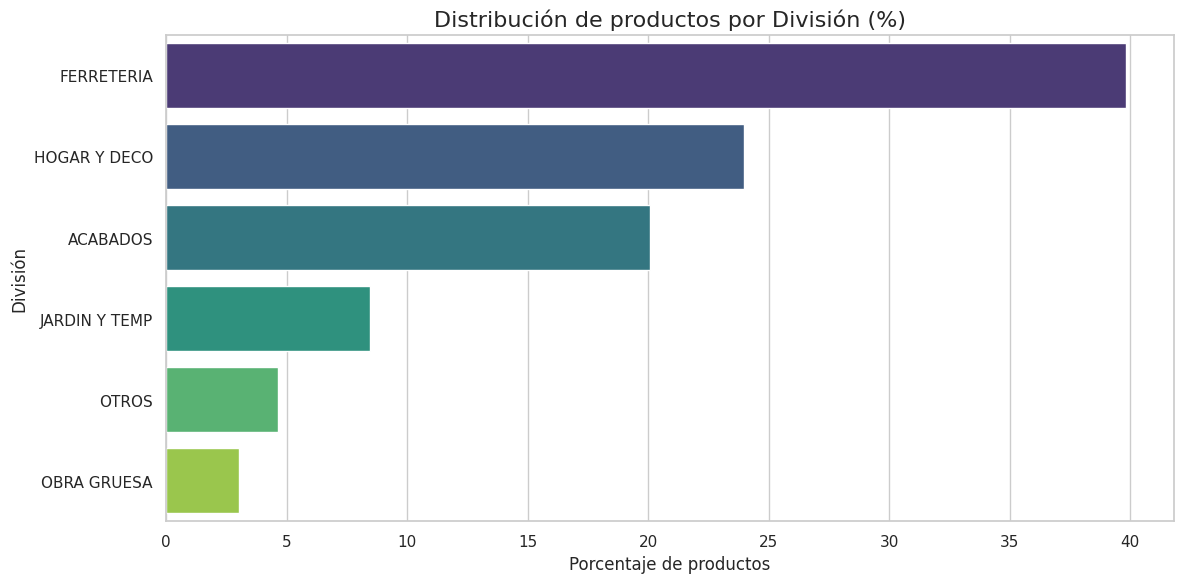

In [ ]:
# productos por división
division_counts = df_prod['DES_DIV'].value_counts(normalize=True) * 100
display(division_counts)
# Gráfico
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(
    x=division_counts.values,
    y=division_counts.index,
    palette="viridis"
)
plt.title("Distribución de productos por División (%)", fontsize=16)
plt.xlabel("Porcentaje de productos")
plt.ylabel("División")
plt.tight_layout()
plt.show()



df_prod['DES_DIV'].value_counts(normalize=True) * 100

La distribución por división muestra que: el 40 % de los productos pertenece a FERRETERIA, seguido por HOGAR Y DECO (24 %) y ACABADOS (20 %).  

Esto significa que los modelos semánticos aprenderán más vocabulario y contexto de los productos de ferretería y acabados, porque aparecen con más frecuencia.

Esto puede sesgar la representación vectorial, haciendo que el sistema experto sea más preciso en esas divisiones y menos en las minoritarias.

In [ ]:
# Marcas
df_prod['DES_MARCA'].value_counts().sort_values(ascending=False)

,count
DES_MARCA,
ORANGE,5305
SM,3891
BAHCO,1271
BOSCH,1210
WERKEN,1169
...,...
WALLPOPS KIDS,1
HAWAIAN TROPIC,1
LA ROCHELLI,1


El análisis de frecuencia por marca muestra una distribución altamente desbalanceada.  
Marcas como ORANGE y SM concentran la mayoría de los registros, mientras que muchas otras aparecen con muy baja frecuencia.  
Este desbalance puede generar sesgo en la representación semántica, favoreciendo categorías con mayor presencia textual y limitando la calidad de los embeddings para marcas con escasa información.

# 4. Limpieza y Normalización de Datos

In [ ]:
import sys
sys.path.append(UTILS_ROUTE)

from utils_eda import limipiarTexto, eliminarHtml, formatearDescripcion, formatoChunk, getChunkSku

### CHUNK PRODUCTO

In [ ]:
df['CHUNK_PRODUCTO'] = df.apply(formatoChunk, axis=1)
logging.info("CHUNK_PRODUCTO")

Se construyó la variable CHUNK_PRODUCTO, que consolida la información textual relevante de cada producto
(descripción, marca, área, departamento, línea y procedencia).  
Esta normalización textual facilita la posterior generación de embeddings semánticos, al ofrecer un contexto unificado y limpio por registro.


In [ ]:
# Se extrae una muestra aleatoria de 5 descripciones
age_array = df.sample(n=5)['CHUNK_PRODUCTO'].to_numpy()
logging.info("Se generó una muestra aleatoria de 5 registros de 'CHUNK_PRODUCTO' para validación visual del texto resultante.")
age_array

array(['ponchador para conector original de la marca opalux del area de electricidad para los cables de la linea accesorios p/ cables de procedencia nacional',
       'farol osaka de la marca josfel del area de iluminacion para los iluminacion exterior de la linea faroles de procedencia nacional',
       'banco woody 70 x 27 cm de la marca atmosphera del area de aire libre y temporada para los terrazas de la linea deco terraza de procedencia importado',
       'colgante espejo negro e27 de la marca sonlux del area de iluminacion para los iluminacion decorativa de la linea colgantes modernos de procedencia nacional',
       'carretilla con 3 bandejas de la marca bahco del area de herramientas para los herramientas de mano de la linea cajas de herramientas de procedencia nacional'],
      dtype=object)

### ATRIBUTOS CLAVE (`CHUNK_FICHA`)

In [ ]:
df_atr_clave = pd.DataFrame(columns=["SKU", "CHUNK_FICHA"])

for sku, grupo in df_ficha.groupby("SKU"):
    atributos = ", ".join([f"{row['KEY'].strip().lower()} {str(row['VALUE']).strip().lower()}" for _, row in grupo.iterrows()])
    texto = f"sku {sku}, {atributos}"
    df_atr_clave.loc[len(df_atr_clave)] = [sku, atributos]
logging.info("CHUNK_FICHA")
df_atr_clave

,SKU,CHUNK_FICHA
0,10001,"volumen del producto 0, ean 6928073681268, tip..."
1,10002,"volumen del producto 0, ean 6928073680025, tip..."
2,10004,"volumen del producto 0, ean 6928073680650, col..."
3,10005,"volumen del producto 0, ean 6928073680049, col..."
4,10006,"volumen del producto 0, ean 6925582161113, col..."
...,...,...
101134,165467,"altura del producto 16.5 cm, ancho del product..."
101135,165468,"altura del producto 8 cm, ancho del producto 2..."
101136,165469,"altura del producto 0.035 cm, ancho del produc..."
101137,165470,"altura del producto 0.045 cm, ancho del produc..."


In [ ]:
age_array = df_atr_clave.sample(n=5)['CHUNK_FICHA'].to_numpy()
logging.info("Se generó una muestra aleatoria de 5 registros de 'CHUNK_FICHA' para validación visual del texto resultante.")
age_array

array(['acabado esmaltado/brillante, altura del producto 59 cm, ancho del producto 59 cm, volumen del producto 0, ean 7751239120276, tipo de producto piso, modelo dallas, color beige, material arcilla, garantía 5 años, procedencia nacional, país de origen perú',
       'altura del producto 26.20 cm, ancho del producto 8.10 cm, profundidad del producto 17.80 cm, volumen del producto 3777.516, ean 88381739566, medidas 8.10x17.80x26.20, tipo de producto taladro, modelo dhp486z, color verde, material poliamida, garantía 1 año, procedencia nacional, país de origen china',
       'volumen del producto 0, ean 7754762000268, color no aplica, garantía 1 año, procedencia nacional',
       'altura del producto 10.00 cm, ancho del producto 9.00 cm, profundidad del producto 4.00 cm, volumen del producto 360, ean 4047024604933, medidas 9.00x4.00x10.00, tipo de producto bocina, modelo cr8 / paquerinha, color negro, material acero, garantía 1 año, procedencia nacional, país de origen alemania',
      

### NORMALIZAR TEXTO

In [ ]:
df_desc['VALUE'] = df_desc['VALUE'].fillna('')
df_desc['VALUE'] = df_desc.apply(eliminarHtml, axis=1)
logging.info("limpiando descripción de producto de variables html y caracteres residuales")

In [ ]:
df_desc

,SKU,KEY,VALUE
0,113229,Características,Esta duradera casa para mascotas es muy resist...
1,113229,Observaciones,Combina un patrón de punto clásico con diseño ...
2,113229,Descripción Emocional,Esta duradera casa para mascotas es muy resist...
3,113231,Características,"Fabricada en resina duradera, esta casa para p..."
4,113231,Observaciones,"Con un diseño para todo tipo de clima, esta ca..."
...,...,...,...
273985,154248,Características,Cuerda con mango antideslizante ergonómico. La...
273986,154248,Observaciones,No aplica
273987,154248,Recomendaciones De Uso,Ideal para realizar entrenamiento mediante sal...
273988,154248,Advertencia de uso,No permita a los niños usar este producto sin ...


In [ ]:
# toma 50 textos y revisarlos como análisis semántico

# age_array = df_desc.loc[df_desc['KEY']=='Descripción Emocional'].sample(n=50)['VALUE'].to_numpy()
#age_array = dfd.loc[dfd['KEY']=='Características'].sample(n=50)['VALUE'].to_numpy()
#age_array = dfd.loc[dfd['KEY']=='Observaciones'].sample(n=50)['VALUE'].to_numpy()

### Consolidación semántica de descripciones por producto (SKU)

In [ ]:
dfx = pd.DataFrame(columns=["SKU", "CHUNK_DESCRIPCION", "CHUNK_CARACTERISTICAS", "CHUNK_OBSERVACIONES", "CHUNK_RECOMENDACIONES"])

for sku, grupo in df_desc.groupby("SKU"):
    carac=''
    obser=''
    descr=''
    recom=''
    for _, row in grupo.iterrows():
        match row['KEY']:
            case 'Características':
                carac=row['VALUE']
            case 'Observaciones':
                obser=row['VALUE']
            case 'Descripción Emocional':
                descr=row['VALUE']
            case 'Recomendaciones De Uso':
                recom=row['VALUE']
    dfx.loc[len(dfx)] = [sku, descr, carac, obser, recom]

dfx

,SKU,CHUNK_DESCRIPCION,CHUNK_CARACTERISTICAS,CHUNK_OBSERVACIONES,CHUNK_RECOMENDACIONES
0,10001,Atornillador de uso doméstico para realizar di...,"Ligero. Conveniente, cómodo y fácil de usar. D...",,Usar lentes de seguridad al momento de utiliza...
1,10006,Los rotomartillos son herramientas muy parecid...,,,Utilizar protectores auditivos y mascarilla p...
2,10007,Promart y Total traen para ti esta potente sie...,,,"Deberemos utilizar gafas protectoras y nunca,..."
3,10010,Realiza toda clase de trabajos utilizando sola...,,,
4,10013,Realiza distintos trabajos con este potente so...,,,
...,...,...,...,...,...
71809,165467,,Doble funcionalidad para distintos tipos de cá...,,
71810,165468,,"Saltea, sofríe y cocina saludable. Antiadheren...",,
71811,165469,,"Colorido y fácil de limpiar. Ideal para niños,...",,
71812,165470,,"Aporta color y estilo a tu mesa. Resistente, a...",,


Observamos que hay celdas con valores vacios, lo tendremos en cuenta a normalizar.

### TABLA NORMALIZADA

In [ ]:
# Productos - Ficha Tecnica - Descripcion y recomendaciones
df_normalizada = pd.merge(df, df_atr_clave, on='SKU', how='left')
df_normalizada = pd.merge(df_normalizada, dfx, on='SKU', how='left')
df_normalizada.head(3)

,SKU,DESCRIPCION,DES_DIV,DES_AREA,DES_DPTO,DES_LIN,DES_MARCA,DES_PROCE,FEC_CRE,FEC_MOD,URL,CHUNK_PRODUCTO,CHUNK_FICHA,CHUNK_DESCRIPCION,CHUNK_CARACTERISTICAS,CHUNK_OBSERVACIONES,CHUNK_RECOMENDACIONES
0,10236,OVALIN CIRCULAR P/SOBREP ORANGE VIDRIOTRANSPAR...,ACABADOS,BAÑOS,SANITARIOS,OVALINES,ORANGE,IMPORTADO,2011-03-07,2025-07-14,https://promart.vteximg.com.br/arquivos/ids/38...,ovalin circular para sobreponer vidriotranspar...,"acabado brillante, tamaño del producto moderad...",Moderniza la decoración de tu baño con este ov...,Ovalín para sobreponer en mesada de baño hecho...,Se recomienda complementar la instalación del ...,Al momento de instalar no usar cemento ni arci...
1,10237,OVALIN CIRCULAR P/SOBREP ORANGE VIDRIO PAVONADO,ACABADOS,BAÑOS,SANITARIOS,OVALINES,ORANGE,IMPORTADO,2011-03-07,2025-07-14,https://promart.vteximg.com.br/arquivos/ids/50...,ovalin circular para sobreponer vidrio pavonad...,"acabado pavonado, tamaño del producto moderado...",Moderniza la decoración de tu baño con este ov...,Ovalín para sobreponer en mesada de baño hecho...,Se recomienda complementar la instalación del ...,Al momento de instalar no usar cemento ni arci...
2,10298,LLAVE DUCHA ORANGE FROST S/SALIDA,ACABADOS,BAÑOS,GRIFERIA DE BAÑO,LLAVE DUCHA,ORANGE,IMPORTADO,2011-03-16,2025-07-14,https://promart.vteximg.com.br/arquivos/ids/51...,llave ducha frost sin salida de la marca orang...,"acabado cromado, altura del producto 6.00 cm, ...",Dale un toque elegante a la grifería de tu duc...,Llave para ducha convencional de cuerpo interi...,"Previo a la compra, verificar si se puede adap...",Maniobrar con cuidado para evitar el deterioro...


### Llenar valores vacios

In [ ]:
# columnas con nulos
col_nulos_n = df_normalizada.columns[df_normalizada.isna().any()]
logging.info(f"columnas con datos nulos: {col_nulos_n}")
df_normalizada[col_nulos_n] = df_normalizada[col_nulos_n].fillna('')
logging.info(f"Se rellenaron con cadena vacía las columnas con valores nulos: {list(col_nulos_n)}")
col_nulos_n

Index(['CHUNK_FICHA', 'CHUNK_DESCRIPCION', 'CHUNK_CARACTERISTICAS',
       'CHUNK_OBSERVACIONES', 'CHUNK_RECOMENDACIONES'],
      dtype='object')

# 5. Guardar Datos

In [ ]:
df_normalizada.to_csv(f'{MAIN_ROUTE}/data/processed/productos_corpus.csv', index=False)
logging.info("Se actualiza el corpus (productos_corpus.csv)")

# 6. Análisis exploratorio del texto y patrones semánticos

In [ ]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import pandas as pd

# Lista de stopwords en español
stopwords_es = stopwords.words('spanish')

def imprimirGraficoTfIdf(lista):
    # Tu lista de textos (puedes reemplazarla si ya la tienes cargada)
    textos = lista[1:]

    # Vectorizar con TF-IDF y stopwords en español
    vectorizer = TfidfVectorizer(stop_words=stopwords_es)
    tfidf_matrix = vectorizer.fit_transform(textos)

    # Sumar los pesos TF-IDF por palabra en todo el corpus
    suma_tfidf = tfidf_matrix.sum(axis=0).A1
    palabras = vectorizer.get_feature_names_out()

    # Crear DataFrame con resultados
    dfx = pd.DataFrame({'palabra': palabras, 'tfidf': suma_tfidf})
    dfx = dfx.sort_values(by='tfidf', ascending=False).head(20)

    # Graficar
    plt.figure(figsize=(10, 6))
    plt.barh(dfx['palabra'], dfx['tfidf'], color='skyblue')
    plt.xlabel('Peso TF-IDF total')
    plt.title(f'Producto con SKU {sku} \n Top 20 palabras más importantes (TF-IDF)')
    plt.gca().invert_yaxis()
    plt.tight_layout()

    plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


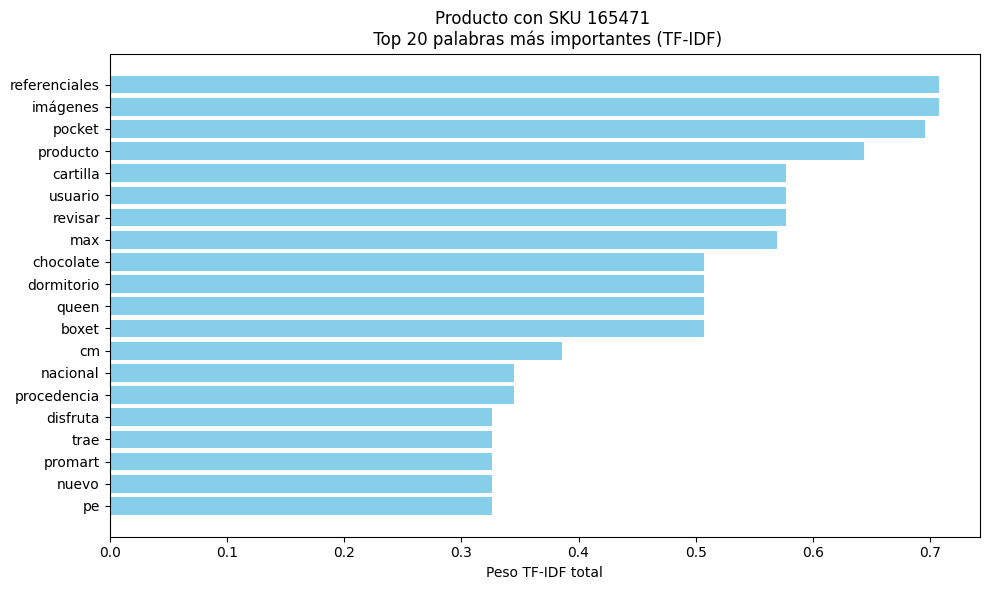

In [ ]:
sku_ejemplo = 165375

imprimirGraficoTfIdf(getChunkSku(df_normalizada,sku_ejemplo))
logging.info(f"Análisis TF-IDF aplicado al SKU {sku_ejemplo}.")


CONCLUSION:

Se toma como ejemplo el producto identificado con el SKU 165375 para aplicar el análisis TF-IDF sobre sus diferentes descripciones textuales.
El resultado revela la presencia de términos específicos como “pocket”, “queen”, “boxet”, “dormitorio” y “chocolate”, los cuales describen características propias del producto y sugieren su pertenencia a la categoría de ropa de cama o colchonería.

Asimismo, se observan términos de tipo contextual u operativo como “referenciales”, “imágenes”, “usuario” y “revisar”, que parecen corresponder a fragmentos informativos o etiquetas utilizadas en la gestión de fichas técnicas y no al contenido semántico principal.

En conjunto, el análisis muestra que las descripciones del producto contienen información semánticamente rica y relevante para representar el dominio del retail, aunque mezclada con texto auxiliar o administrativo.
Se recomienda una limpieza adicional de este tipo de términos antes de generar los embeddings, con el fin de mejorar la coherencia y representatividad del espacio vectorial resultante.


# DECISIONES PARA EL PROXIMO SPRINT

## Limpieza semántica avanzada:
Aplicar técnicas de text preprocessing más robustas (tokenización, lematización, eliminación de texto referencial o administrativo) antes de la vectorización.

## Validación de embeddings y evaluación inicial:
Implementar un modelo base (all-MiniLM-L6-v2) para generar los primeros embeddings del corpus procesado y analizar su coherencia mediante búsquedas semánticas o clustering.

## Conversión temporal y análisis cronológico

Transformar los campos FEC_CRE y FEC_MOD a formato datetime permitirá analizar la antigüedad y evolución de las descripciones de productos.
Esto ayudará a identificar registros desactualizados, seguir cambios en el lenguaje comercial y asegurar que el sistema experto se base siempre en información vigente y coherente con la realidad del catálogo.

# Logs automáticos

Todos los procesos relevantes del EDA (carga, limpieza, selección, unión, normalización y exportación de datos) se registran en:

logs/01_EDA.log

Cada acción queda trazada con hora, nivel de detalle e impacto en el dataset.